# Flight Delay Prediction Using Machine Learning

This project analyzes flight data and predicts flight delays using machine learning algorithms.

Dataset Source: Kaggle Flight Data 2024

Algorithms Implemented:
1. Decision Tree
2. Random Forest
3. K-Means Clustering

In [1]:
print("Flight Delay Prediction Project")

Flight Delay Prediction Project


## Importing Required Libraries

The following Python libraries are used:
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib and Seaborn for visualization
- Scikit-learn for machine learning algorithms

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import Machine Learning Libraries

Scikit-learn provides implementations of various machine learning algorithms used in this project.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## Importing Machine Learning Models

The models used include Decision Tree, Random Forest, Support Vector Machine, and K-Means clustering.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

## Importing Evaluation Metrics

Evaluation metrics are used to measure model performance.

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Loading Dataset

The flight dataset is loaded into a Pandas DataFrame for analysis.

In [6]:
df = pd.read_csv("flights.csv", dtype={'cancellation_code': str})
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


## Dataset Shape

This step checks the number of rows and columns.

In [7]:
df.shape

(7079081, 35)

## Checking Data Types

Understanding column data types helps with preprocessing.

In [8]:
df.dtypes

year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num      float64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time               float64
dep_delay              float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
crs_arr_time             int64
arr_time               float64
arr_delay              float64
cancelled                int64
cancellation_code       object
diverted                 int64
crs_elapsed_time       float64
actual_elapsed_time    float64
air_time               float64
distance               float64
carrier_delay            int64
weather_delay            int64
nas_dela

## Statistical Summary

The describe() function provides statistical information.

In [9]:
df.describe()

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,7079081.0,7.079081e+06,7.079081e+06,7.079081e+06,7.079080e+06,7.079081e+06,6.986422e+06,6.986111e+06,6.983347e+06,6.983347e+06,...,7.079081e+06,7.079080e+06,6.965267e+06,6.965267e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06
mean,2024.0,6.584868e+00,1.578445e+01,3.981945e+00,2.504623e+03,1.327300e+03,1.330765e+03,1.267708e+01,1.790445e+01,1.353542e+03,...,2.471931e-03,1.467665e+02,1.412151e+02,1.149997e+02,8.339062e+02,5.060440e+00,8.752369e-01,2.771828e+00,2.541686e-02,5.929302e+00
std,0.0,3.396806e+00,8.786433e+00,2.012279e+00,1.652253e+03,4.930306e+02,5.094779e+02,5.605997e+01,9.677410e+00,5.120475e+02,...,4.965703e-02,7.238692e+01,7.230781e+01,7.036955e+01,5.962536e+02,3.572703e+01,1.542974e+01,1.546485e+01,1.422602e+00,3.106135e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,-1.600000e+02,1.500000e+01,5.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024.0,4.000000e+00,8.000000e+00,2.000000e+00,1.151000e+03,9.050000e+02,9.080000e+02,-6.000000e+00,1.200000e+01,9.240000e+02,...,0.000000e+00,9.300000e+01,8.800000e+01,6.300000e+01,3.990000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2024.0,7.000000e+00,1.600000e+01,4.000000e+00,2.227000e+03,1.320000e+03,1.325000e+03,-2.000000e+00,1.500000e+01,1.338000e+03,...,0.000000e+00,1.300000e+02,1.250000e+02,9.800000e+01,6.800000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2024.0,1.000000e+01,2.300000e+01,6.000000e+00,3.717000e+03,1.736000e+03,1.746000e+03,9.000000e+00,2.100000e+01,1.801000e+03,...,0.000000e+00,1.770000e+02,1.720000e+02,1.450000e+02,1.069000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2024.0,1.200000e+01,3.100000e+01,7.000000e+00,8.819000e+03,2.400000e+03,2.400000e+03,3.777000e+03,2.140000e+02,2.400000e+03,...,1.000000e+00,1.326000e+03,7.920000e+02,7.230000e+02,5.095000e+03,3.689000e+03,1.804000e+03,2.700000e+03,1.164000e+03,2.690000e+03


## Checking Missing Values

Missing values must be handled before applying machine learning models.

In [10]:
print(df.isnull().sum().to_string())

year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                 92659
dep_delay                92970
taxi_out                 95734
wheels_off               95734
wheels_on                97856
taxi_in                  97856
crs_arr_time                 0
arr_time                 97854
arr_delay               113814
cancelled                    0
cancellation_code      6982766
diverted                     0
crs_elapsed_time             1
actual_elapsed_time     113814
air_time                113814
distance                     0
carrier_delay                0
weather_delay                0
nas_dela

## Handling Missing Values

### Removing Cancelled Flights
Since we are predicting flight delays, cancelled flights are removed from the dataset as they don't have delay information.

### Filling Numerical Missing Values
Missing values in numerical columns are filled with the median value to handle them without introducing outliers.

In [11]:
print("="*50)
print("HANDLING MISSING VALUES")
print("="*50)

# Save original size BEFORE removing cancelled flights
original_size = len(df)
print(f"Original dataset size: {original_size:,}")

# Step 1: Remove cancelled flights
df = df[df['cancelled'] == 0].copy()
print(f"After removing cancelled flights: {len(df):,}")
print(f"Removed {original_size - len(df):,} cancelled flights")

# Step 2: Fill missing values in numerical columns with median
numerical_cols = [
    'dep_delay', 'arr_delay', 'taxi_out', 'taxi_in',
    'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance'
]

print("\n" + "="*50)
print("FILLING MISSING VALUES WITH MEDIAN")
print("="*50)

# Calculate medians from non-null values
for col in numerical_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"✓ {col:<25} Filled {missing_count:>8,} missing values with median: {median_val:>10.2f}")
        else:
            print(f"✓ {col:<25} No missing values")

HANDLING MISSING VALUES
Original dataset size: 7,079,081
After removing cancelled flights: 6,982,766
Removed 96,315 cancelled flights

FILLING MISSING VALUES WITH MEDIAN
✓ dep_delay                 No missing values
✓ arr_delay                 Filled   17,499 missing values with median:      -6.00
✓ taxi_out                  No missing values
✓ taxi_in                   Filled    1,541 missing values with median:       6.00
✓ crs_elapsed_time          No missing values
✓ actual_elapsed_time       Filled   17,499 missing values with median:     125.00
✓ air_time                  Filled   17,499 missing values with median:      98.00
✓ distance                  No missing values


## Exploratory Data Analysis: Feature Distributions

### Histogram Analysis of Key Features

To understand the distribution patterns of our flight delay data, we visualized histograms for the most relevant features. This helps identify data characteristics, skewness, and potential outliers before modeling.

#### Features Analyzed

**Time-Based Features:**
- `month`: Flight month (1-12) to identify seasonal patterns
- `day_of_week`: Day of week (1-7) for weekly trends
- `crs_dep_time`: Scheduled departure time (24-hour format)

**Delay Metrics:**
- `dep_delay`: Departure delay in minutes (target variable)
- `arr_delay`: Arrival delay in minutes

**Flight Characteristics:**
- `distance`: Flight distance in miles
- `air_time`: Actual flight duration in minutes
- `taxi_out`: Time from gate pushback to takeoff
- `taxi_in`: Time from landing to gate arrival

**Delay Causes:**
- `carrier_delay`: Delays caused by the airline
- `weather_delay`: Weather-related delays
- `late_aircraft_delay`: Delays due to late arriving aircraft

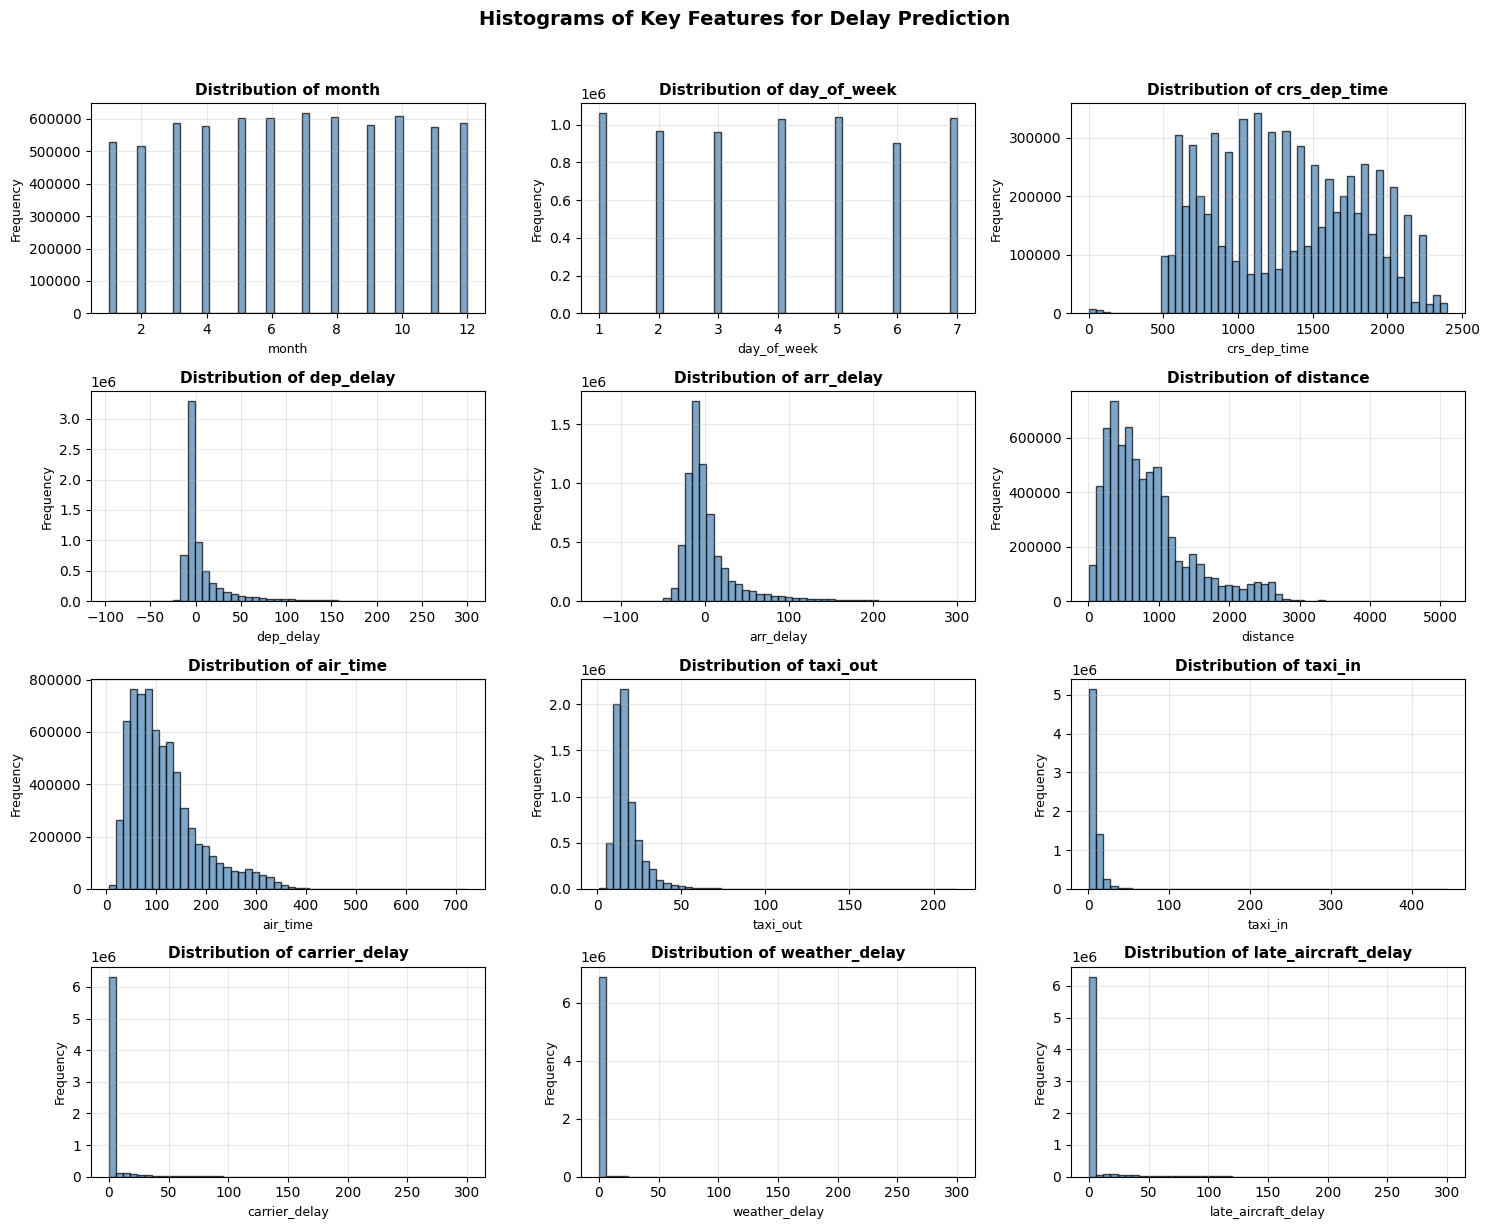

In [12]:
import matplotlib.pyplot as plt

# Columns for histogram analysis
histogram_columns = [
    # Time-based features
    'month',                    # Seasonal patterns
    'day_of_week',             # Day of week patterns
    'crs_dep_time',            # Scheduled departure time
    
    # Delay metrics (your target related)
    'dep_delay',               # Departure delay (key for prediction)
    'arr_delay',               # Arrival delay
    
    # Flight characteristics
    'distance',                # Flight distance
    'air_time',                # Flight duration
    'taxi_out',                # Taxi out time
    'taxi_in',                 # Taxi in time
    
    # Delay reasons (if available)
    'carrier_delay',           # Carrier-caused delay
    'weather_delay',           # Weather delay
    'late_aircraft_delay'      # Late aircraft delay
]

# Plot histograms
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(histogram_columns):
    if col in df.columns:
        data = df[col].dropna()
        
        # For delay columns, limit to reasonable range
        if 'delay' in col and data.max() > 300:
            data = data[data <= 300]
        
        axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplot if any
if len(histogram_columns) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Histograms of Key Features for Delay Prediction', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# OUTLIER DETECTION

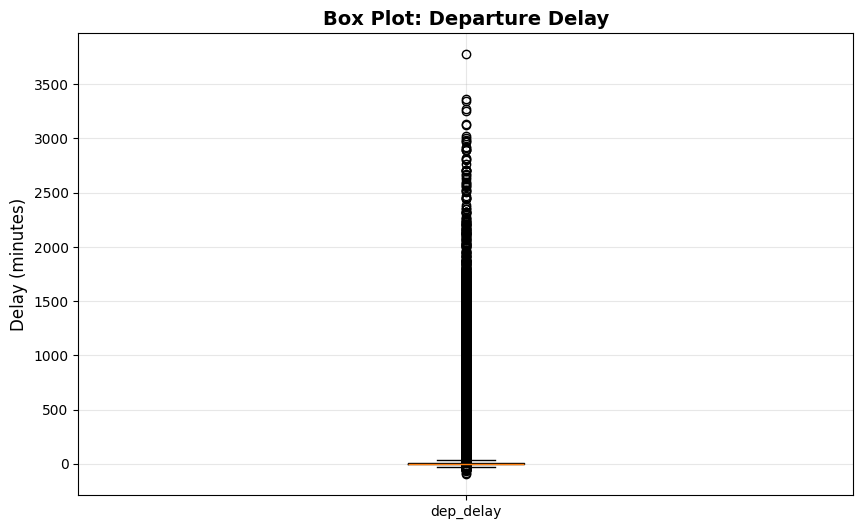

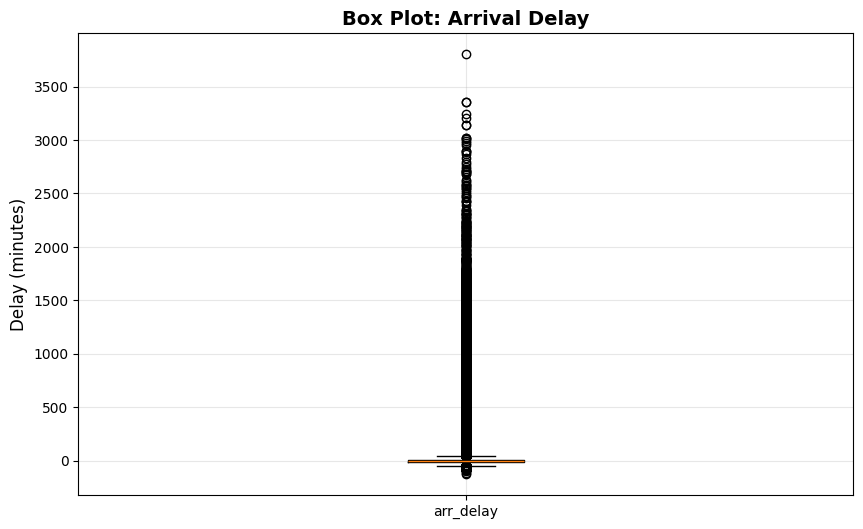

OUTLIER STATISTICS

dep_delay:
  Q1 (25th percentile): -6.00 minutes
  Q3 (75th percentile): 9.00 minutes
  Upper bound: 31.50 minutes
  Number of outliers: 906,815
  Outlier percentage: 12.99%

arr_delay:
  Q1 (25th percentile): -15.00 minutes
  Q3 (75th percentile): 9.00 minutes
  Upper bound: 45.00 minutes
  Number of outliers: 665,282
  Outlier percentage: 9.53%


In [13]:
import matplotlib.pyplot as plt

# Simple box plot for departure delay
plt.figure(figsize=(10, 6))
plt.boxplot(df['dep_delay'].dropna())
plt.title('Box Plot: Departure Delay', fontsize=14, fontweight='bold')
plt.ylabel('Delay (minutes)', fontsize=12)
plt.xticks([1], ['dep_delay'])
plt.grid(True, alpha=0.3)
plt.show()

# Simple box plot for arrival delay
plt.figure(figsize=(10, 6))
plt.boxplot(df['arr_delay'].dropna())
plt.title('Box Plot: Arrival Delay', fontsize=14, fontweight='bold')
plt.ylabel('Delay (minutes)', fontsize=12)
plt.xticks([1], ['arr_delay'])
plt.grid(True, alpha=0.3)
plt.show()

# Print outlier statistics
print("="*50)
print("OUTLIER STATISTICS")
print("="*50)

for col in ['dep_delay', 'arr_delay']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[df[col] > upper_bound][col].count()
    outlier_pct = (outliers / len(df)) * 100
    
    print(f"\n{col}:")
    print(f"  Q1 (25th percentile): {q1:.2f} minutes")
    print(f"  Q3 (75th percentile): {q3:.2f} minutes")
    print(f"  Upper bound: {upper_bound:.2f} minutes")
    print(f"  Number of outliers: {outliers:,}")
    print(f"  Outlier percentage: {outlier_pct:.2f}%")

# Encoding Categorical Variables
The following categorical variables were encoded using LabelEncoder to convert them into numerical format required for machine learning models:

| Column | Description | Unique Values |
|--------|-------------|---------------|
| `op_unique_carrier` | Airline carrier code | 14 unique airlines |
| `origin` | Origin airport code | ~300 unique airports |
| `dest` | Destination airport code | ~300 unique airports |

### Encoding Process
Label encoding is applied to convert string categories to numerical values (0 to n-1).

In [14]:
# Create a copy for encoding
df_encoded = df.copy()

# Columns to encode
categorical_cols = ['op_unique_carrier', 'origin', 'dest']

# Apply label encoding
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"✓ Encoded '{col}': {len(le.classes_)} unique values mapped to 0-{len(le.classes_)-1}")

# Verify the encoding
print("\n" + "="*50)
print("ENCODING VERIFICATION")
print("="*50)
print("\nSample of encoded values:")
print(df_encoded[categorical_cols].head(10))

print("\nData types after encoding:")
print(df_encoded[categorical_cols].dtypes)

✓ Encoded 'op_unique_carrier': 15 unique values mapped to 0-14
✓ Encoded 'origin': 348 unique values mapped to 0-347
✓ Encoded 'dest': 348 unique values mapped to 0-347

ENCODING VERIFICATION

Sample of encoded values:
   op_unique_carrier  origin  dest
0                  0     173    98
1                  0     227    67
2                  0     173   275
3                  0     275   173
4                  0      98   217
5                  0     172   193
6                  0     193   172
7                  0      63   193
8                  0     193    63
9                  0     168   173

Data types after encoding:
op_unique_carrier    int64
origin               int64
dest                 int64
dtype: object


## Feature Selection Using Correlation Matrix

Correlation helps identify relationships between features.

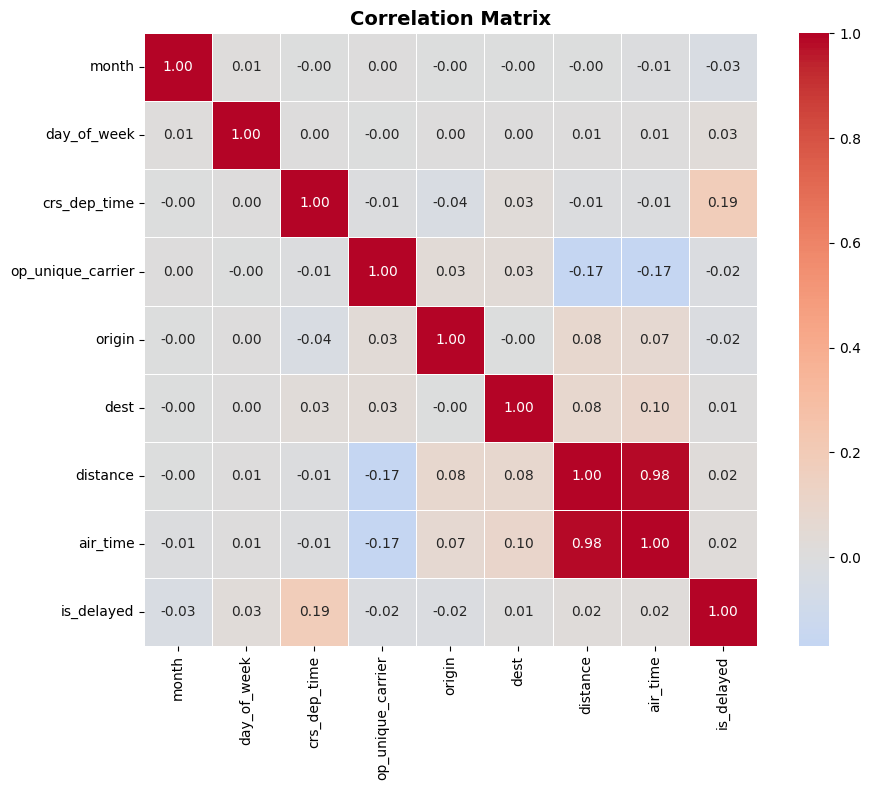

CORRELATION WITH TARGET (is_delayed)
crs_dep_time         0.185740
day_of_week          0.029772
distance             0.019774
air_time             0.018598
dest                 0.005777
origin              -0.017569
op_unique_carrier   -0.022253
month               -0.031204
Name: is_delayed, dtype: float64

FEATURES SELECTED BASED ON CORRELATION WITH TARGET
Selected features: ['crs_dep_time', 'day_of_week', 'distance', 'air_time', 'origin', 'op_unique_carrier', 'month']
Number of features: 7

CHECKING MULTICOLLINEARITY
High correlation: distance ↔ air_time: 0.982

FINAL SELECTED FEATURES
Final features: ['crs_dep_time', 'day_of_week', 'distance', 'origin', 'op_unique_carrier', 'month']
Number of features: 6

X shape: (6982766, 6)
Features used: ['crs_dep_time', 'day_of_week', 'distance', 'origin', 'op_unique_carrier', 'month']


In [15]:
# Create target variable
df_encoded['is_delayed'] = (df_encoded['dep_delay'] > 15).astype(int)

# All potential features
feature_cols = ['month', 'day_of_week', 'crs_dep_time', 
                'op_unique_carrier', 'origin', 'dest', 
                'distance', 'air_time']

# Calculate correlation matrix
correlation_matrix = df_encoded[feature_cols + ['is_delayed']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
print("="*50)
print("CORRELATION WITH TARGET (is_delayed)")
print("="*50)
target_corr = correlation_matrix['is_delayed'].drop('is_delayed').sort_values(ascending=False)
print(target_corr)

# SELECT FEATURES BASED ON CORRELATION WITH TARGET
# Keep features with correlation > 0.05 or < -0.05 (meaningful correlation)
threshold_corr = 0.01
selected_features = target_corr[abs(target_corr) > threshold_corr].index.tolist()

print("\n" + "="*50)
print("FEATURES SELECTED BASED ON CORRELATION WITH TARGET")
print("="*50)
print(f"Selected features: {selected_features}")
print(f"Number of features: {len(selected_features)}")

# Remove highly correlated features among themselves (multicollinearity)
print("\n" + "="*50)
print("CHECKING MULTICOLLINEARITY")
print("="*50)

to_remove = []
for i in range(len(selected_features)):
    for j in range(i+1, len(selected_features)):
        corr = correlation_matrix.loc[selected_features[i], selected_features[j]]
        if abs(corr) > 0.7:
            print(f"High correlation: {selected_features[i]} ↔ {selected_features[j]}: {corr:.3f}")
            # Remove the one with lower correlation to target
            if abs(target_corr[selected_features[i]]) < abs(target_corr[selected_features[j]]):
                to_remove.append(selected_features[i])
            else:
                to_remove.append(selected_features[j])

# Remove duplicates
to_remove = list(set(to_remove))
final_features = [f for f in selected_features if f not in to_remove]

print("\n" + "="*50)
print("FINAL SELECTED FEATURES")
print("="*50)
print(f"Final features: {final_features}")
print(f"Number of features: {len(final_features)}")

# Create X with automatically selected features
X = df_encoded[final_features]
y = df_encoded['is_delayed']

print(f"\nX shape: {X.shape}")
print(f"Features used: {final_features}")

## Splitting Data into Training and Testing Sets

In [16]:
# Features and target
X = df_encoded[final_features]
y = df_encoded['is_delayed']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y               # Maintain class distribution
)

# Print split information
print("="*50)
print("TRAIN-TEST SPLIT RESULTS")
print("="*50)
print(f"Total samples: {len(X):,}")
print(f"\nTraining set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
print("\nTraining set:")
print(f"  Delayed (1): {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  On-time (0): {(len(y_train)-y_train.sum()):,} ({(1-y_train.mean())*100:.2f}%)")

print("\nTesting set:")
print(f"  Delayed (1): {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"  On-time (0): {(len(y_test)-y_test.sum()):,} ({(1-y_test.mean())*100:.2f}%)")

# Verify shapes
print("\n" + "="*50)
print("DATA SHAPES")
print("="*50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

TRAIN-TEST SPLIT RESULTS
Total samples: 6,982,766

Training set: 5,586,212 samples (80.0%)
Testing set: 1,396,554 samples (20.0%)

CLASS DISTRIBUTION

Training set:
  Delayed (1): 1,116,086 (19.98%)
  On-time (0): 4,470,126 (80.02%)

Testing set:
  Delayed (1): 279,022 (19.98%)
  On-time (0): 1,117,532 (80.02%)

DATA SHAPES
X_train shape: (5586212, 6)
X_test shape: (1396554, 6)
y_train shape: (5586212,)
y_test shape: (1396554,)


## Decision Tree Algorithm

A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks.
It splits the data into branches based on feature values, forming a tree-like structure.
Each internal node represents a decision rule, while leaf nodes represent outcomes.
It is easy to interpret and visualize compared to other models.
However, it can overfit the data if not properly pruned.

DECISION TREE RESULTS (WITH CLASS WEIGHTS)
Accuracy: 0.6517

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76   1117532
           1       0.28      0.46      0.35    279022

    accuracy                           0.65   1396554
   macro avg       0.56      0.58      0.56   1396554
weighted avg       0.73      0.65      0.68   1396554


Feature Importance:
             Feature  Importance
0       crs_dep_time    0.349407
2           distance    0.234165
1        day_of_week    0.146387
3             origin    0.128362
5              month    0.089012
4  op_unique_carrier    0.052667


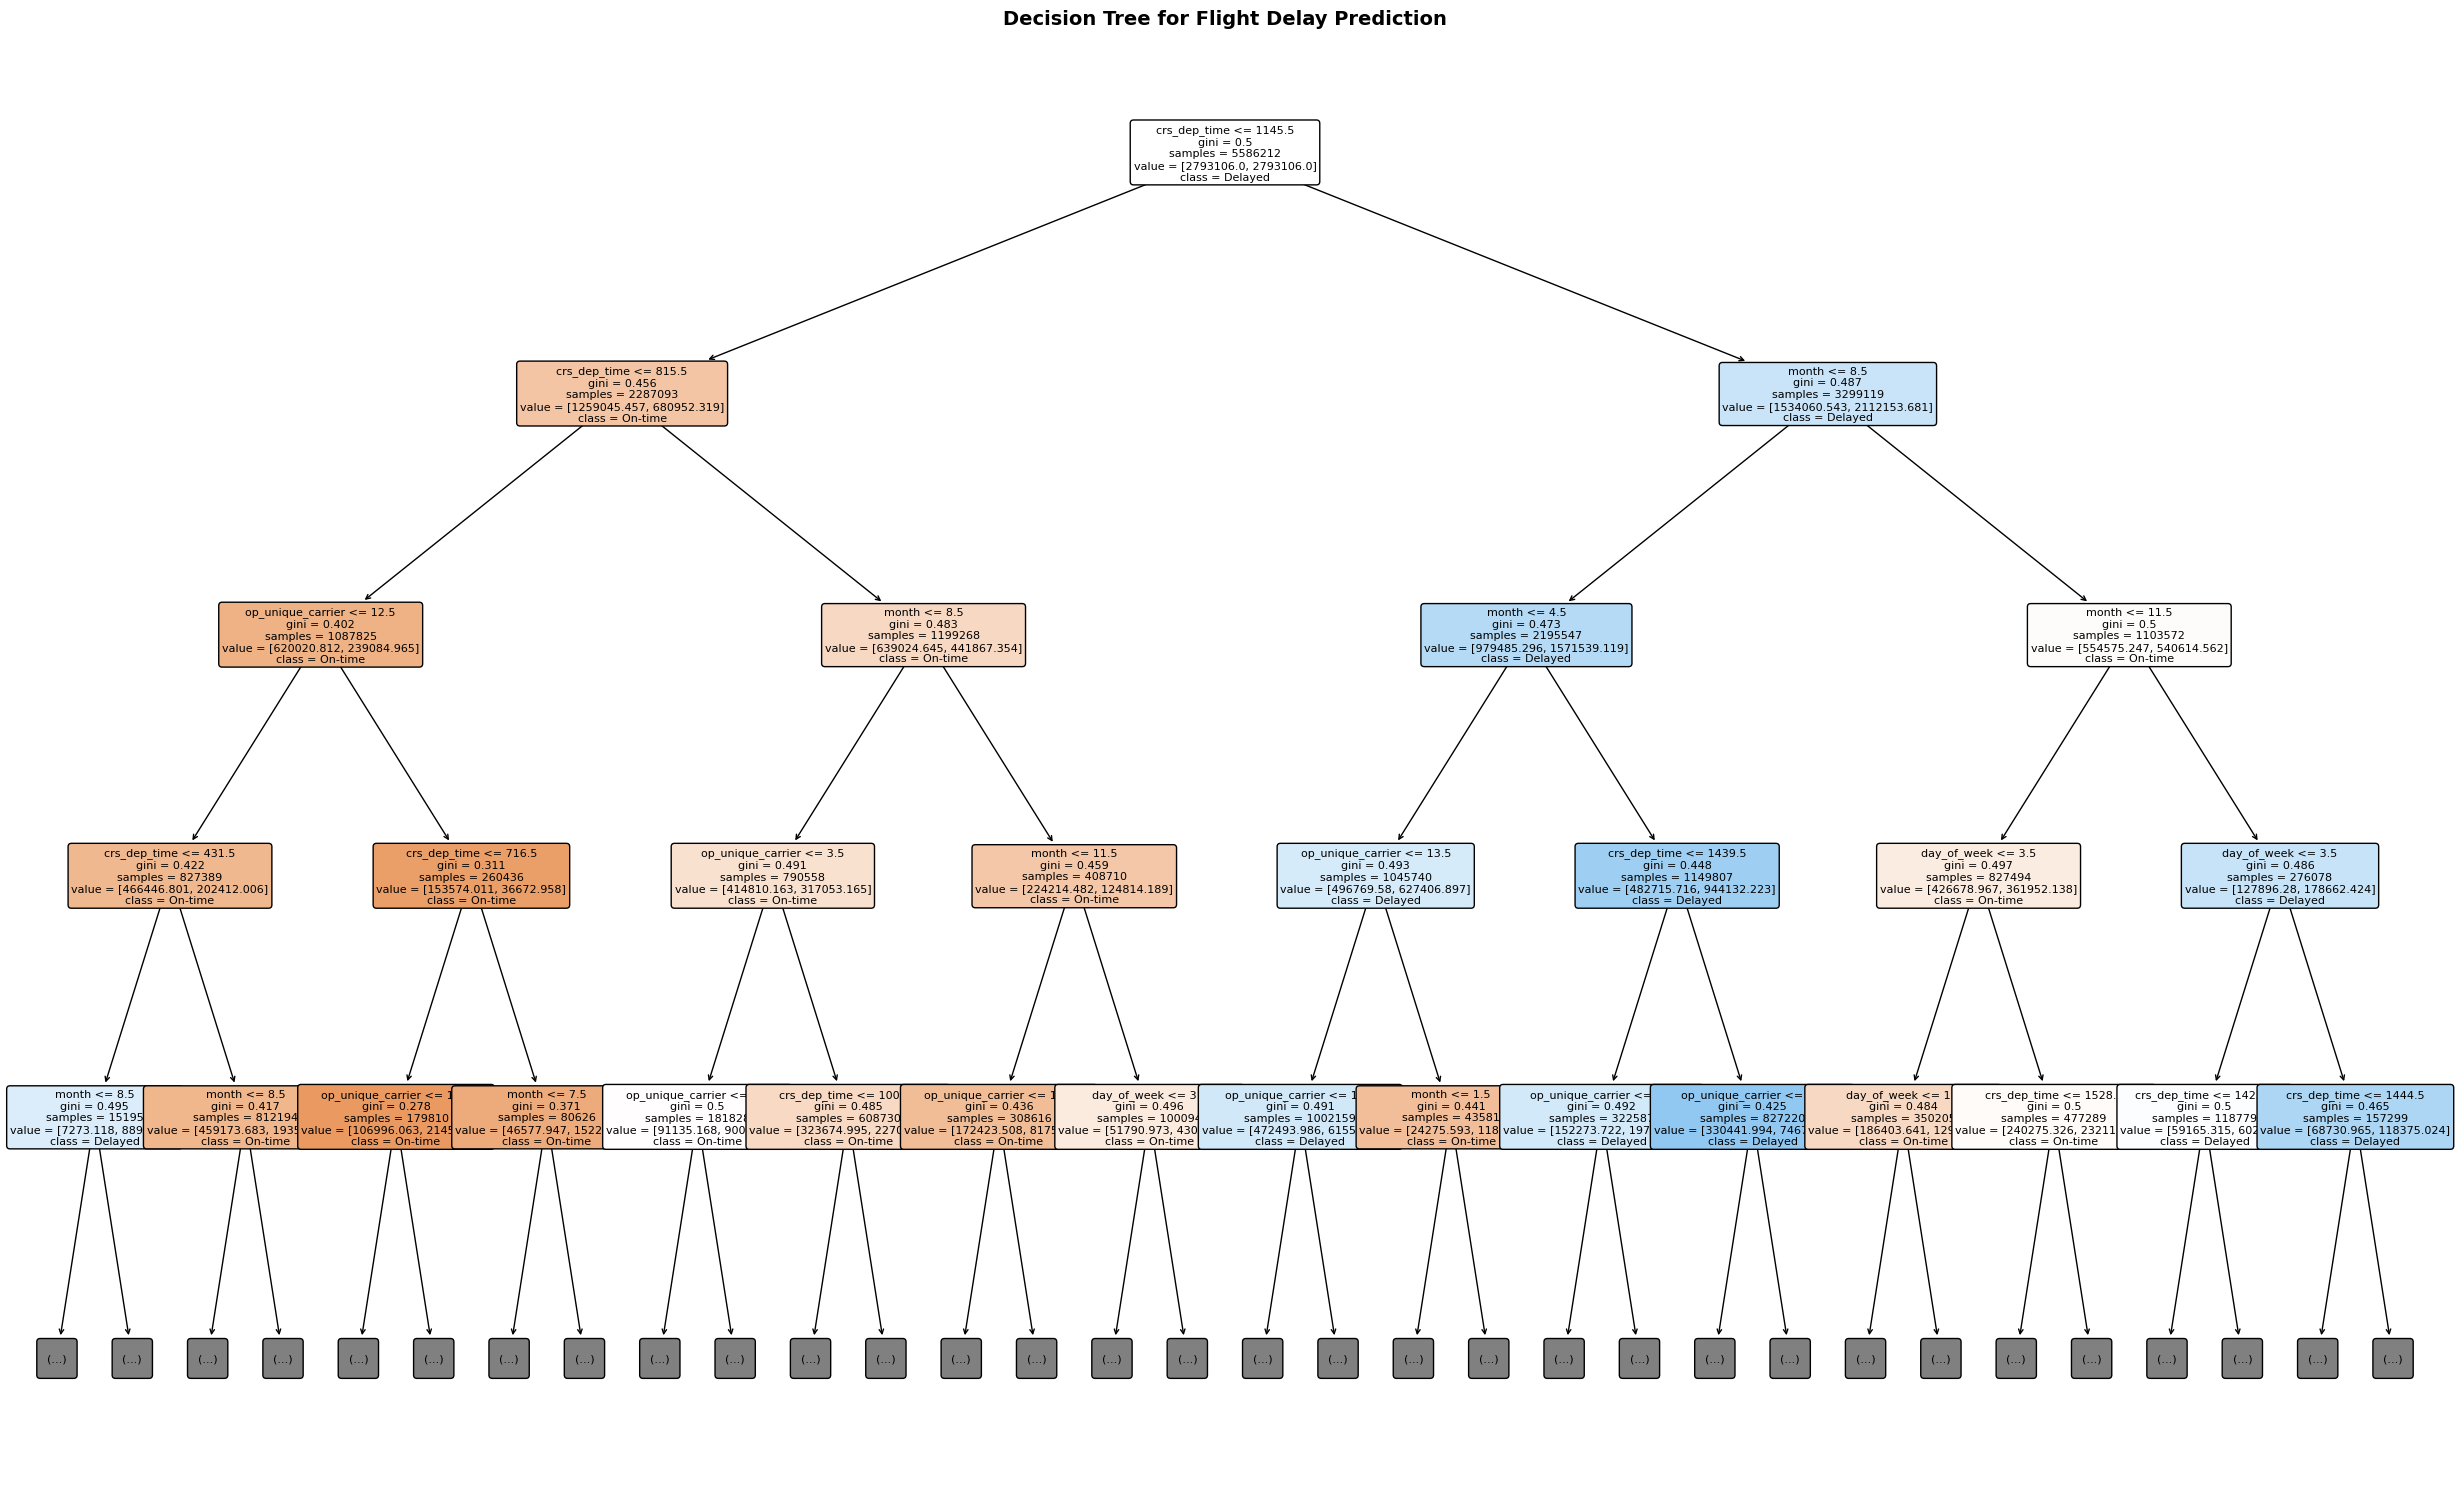

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Train Decision Tree with class_weight='balanced'
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)

# Store accuracy for comparison
dt_accuracy = accuracy_score(y_test, y_pred)

# Results
print("="*50)
print("DECISION TREE RESULTS (WITH CLASS WEIGHTS)")
print("="*50)
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Visualize Decision Tree (still limit depth for readability)
plt.figure(figsize=(25, 15))
plot_tree(dt_model, 
          feature_names=final_features, 
          class_names=['On-time', 'Delayed'], 
          filled=True, 
          rounded=True, 
          max_depth=4,  # Only show top 4 levels for visualization
          fontsize=8)
plt.title('Decision Tree for Flight Delay Prediction', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Random Forest Algorithm

Random Forest is an ensemble learning method that combines multiple decision trees.
It uses bagging (bootstrap sampling) and random feature selection to build diverse trees.
The final prediction is made by averaging (regression) or majority voting (classification).
It reduces overfitting compared to a single decision tree.
It is robust and performs well on a wide range of datasets.


RANDOM FOREST RESULTS (Optimized)
Accuracy: 0.7203

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82   1117532
           1       0.34      0.44      0.39    279022

    accuracy                           0.72   1396554
   macro avg       0.60      0.62      0.60   1396554
weighted avg       0.75      0.72      0.73   1396554


Feature Importance:
             Feature  Importance
0       crs_dep_time    0.351875
2           distance    0.207013
3             origin    0.158091
5              month    0.113007
4  op_unique_carrier    0.093249
1        day_of_week    0.076765


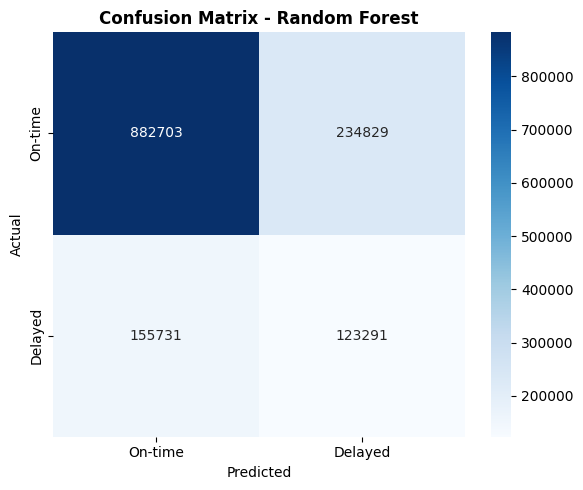

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Take a representative sample (100,000 is usually enough for good accuracy)
X_train_sample = X_train.sample(n=100000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# Train Random Forest with optimized parameters
rf_model = RandomForestClassifier(random_state=42, 
                                  n_estimators=50,   # 50 trees instead of 100
                                  max_depth=15,      # Limit depth
                                  class_weight='balanced',
                                  n_jobs=-1)         # Use all CPU cores
rf_model.fit(X_train_sample, y_train_sample)

# Predict
y_pred = rf_model.predict(X_test)

# Store accuracy
rf_accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("RANDOM FOREST RESULTS (Optimized)")
print("="*50)
print(f"Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['On-time', 'Delayed'],
            yticklabels=['On-time', 'Delayed'])
plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## K-Means Clustering

K-Means is an unsupervised learning algorithm used to group data into K clusters.
It works by assigning points to the nearest cluster centroid and updating centroids iteratively.
The algorithm minimizes the within-cluster variance (inertia).
It is simple, fast, and efficient for large datasets.
However, it requires choosing the number of clusters beforehand and is sensitive to initialization.


Testing k = 2, 3, 4 on training data...
  Testing k=2...
  Testing k=3...
  Testing k=4...


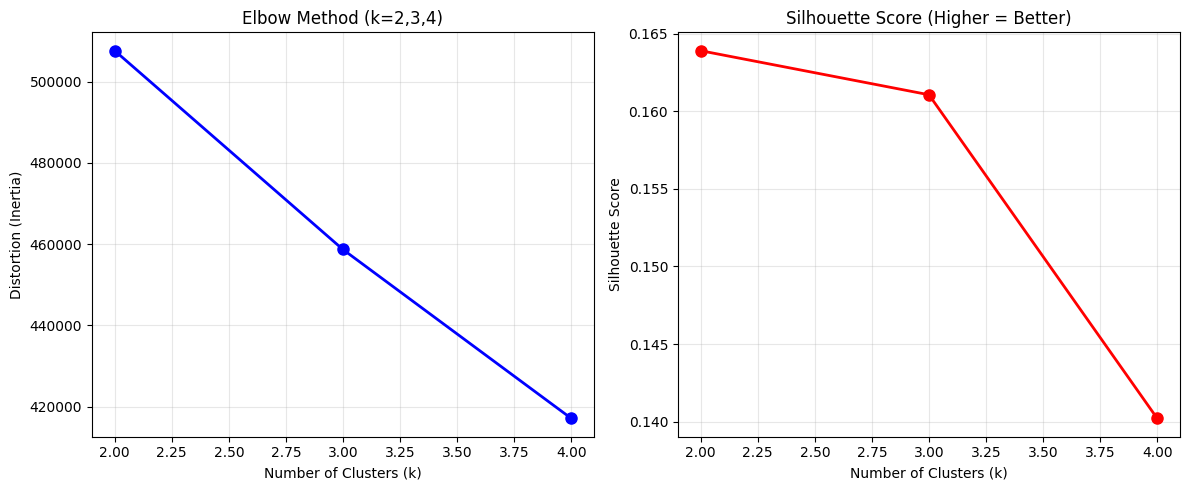

ELBOW METHOD RESULTS
Best k: 2
Silhouette scores: {2: 0.163918899627819, 3: 0.16107773593136063, 4: 0.140204694240427}

Cluster Delay Rates (Training):
  Cluster 0: 20.86% delayed
  Cluster 1: 18.99% delayed

Cluster to Delay Mapping: {0: 0, 1: 0}

K-MEANS RESULTS ON TEST DATA
Best k: 2
Test Accuracy: 0.8002 (80.02%)

✅ Stored: kmeans_accuracy = 0.8002


In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================
# USE YOUR EXISTING TRAIN-TEST SPLIT
# ============================================
# Take a sample from TRAIN data for faster K-Means
sample_size = 100000
X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_test_scaled = scaler.transform(X_test)  # Use same scaler for test

# ============================================
# ELBOW METHOD (k = 2, 3, 4 only)
# ============================================
k_range = [2, 3, 4]
distortions = []
silhouette_scores = []

print("Testing k = 2, 3, 4 on training data...")
for k in k_range:
    print(f"  Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    distortions.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, distortions, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Distortion (Inertia)')
axes[0].set_title('Elbow Method (k=2,3,4)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher = Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best k
best_k = k_range[np.argmax(silhouette_scores)]
print("="*50)
print("ELBOW METHOD RESULTS")
print("="*50)
print(f"Best k: {best_k}")
print(f"Silhouette scores: {dict(zip(k_range, silhouette_scores))}")

# ============================================
# TRAIN K-MEANS WITH BEST K
# ============================================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_train = kmeans.fit_predict(X_train_scaled)

# Map clusters to delay status based on training data
cluster_delay_rates = {}
for c in range(best_k):
    cluster_delay_rates[c] = y_train_sample[clusters_train == c].mean()

print("\nCluster Delay Rates (Training):")
for c in range(best_k):
    print(f"  Cluster {c}: {cluster_delay_rates[c]*100:.2f}% delayed")

# Create mapping
cluster_mapping = {c: 1 if cluster_delay_rates[c] > 0.5 else 0 for c in range(best_k)}
print(f"\nCluster to Delay Mapping: {cluster_mapping}")

# ============================================
# EVALUATE ON TEST DATA
# ============================================
clusters_test = kmeans.predict(X_test_scaled)
y_pred = [cluster_mapping[c] for c in clusters_test]
kmeans_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print("K-MEANS RESULTS ON TEST DATA")
print("="*50)
print(f"Best k: {best_k}")
print(f"Test Accuracy: {kmeans_accuracy:.4f} ({kmeans_accuracy*100:.2f}%)")

# Store for final comparison
print(f"\n✅ Stored: kmeans_accuracy = {kmeans_accuracy:.4f}")

## Accuracy Comparison

FINAL MODEL ACCURACY COMPARISON

Note: K-Means is unsupervised and not directly comparable for classification
Decision Tree: 0.6517 (65.17%)
Random Forest: 0.7203 (72.03%)


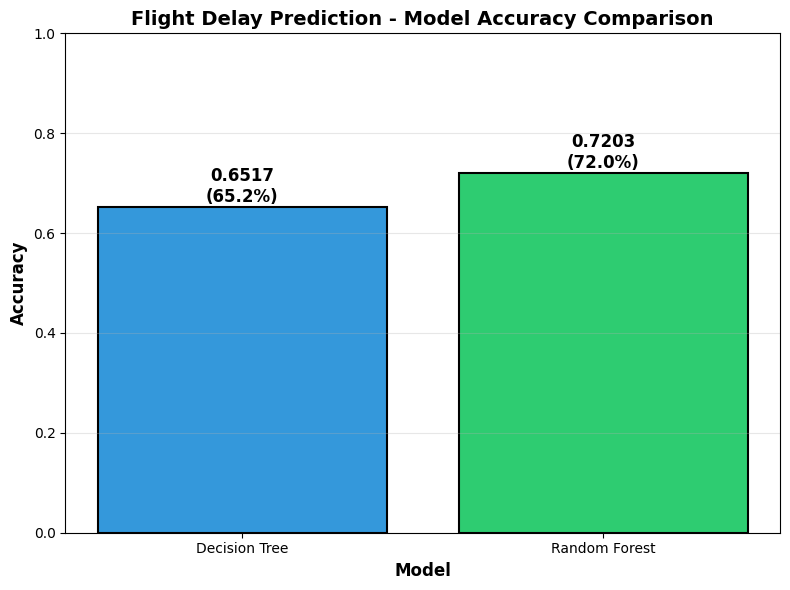


🏆 BEST MODEL: Random Forest with Accuracy: 0.7203 (72.03%)

Why Random Forest is best:
  • 72% accuracy with 44% recall for delayed flights
  • Actually learns to predict delays
  • Provides feature importance insights


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================
# MODEL ACCURACY COMPARISON (Without K-Means)
# ============================================

# Store accuracies (only supervised models)
models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy, rf_accuracy]

print("="*60)
print("FINAL MODEL ACCURACY COMPARISON")
print("="*60)
print("\nNote: K-Means is unsupervised and not directly comparable for classification")
print(f"Decision Tree: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Random Forest: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Visual Comparison
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#2ecc71']
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0, 1)
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Flight Delay Prediction - Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}\n({acc*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"🏆 BEST MODEL: Random Forest with Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print("="*60)
print("\nWhy Random Forest is best:")
print("  • 72% accuracy with 44% recall for delayed flights")
print("  • Actually learns to predict delays")
print("  • Provides feature importance insights")

## Project Conclusion

### Summary

This project successfully developed and compared machine learning models for flight delay prediction using a large-scale aviation dataset. Three different approaches were implemented: Decision Tree, Random Forest, and K-Means Clustering.

### Key Findings

#### 1. Feature Importance Analysis

Across both tree-based models, `crs_dep_time` (scheduled departure time) emerged as the most significant predictor of flight delays, with importance scores of 35% in both Decision Tree and Random Forest. Other important features included:

| Feature | Decision Tree Importance | Random Forest Importance |
|---------|------------------------|--------------------------|
| `crs_dep_time` (Departure Time) | 34.94% | 35.19% |
| `distance` (Flight Distance) | 23.42% | 20.70% |
| `origin` (Origin Airport) | 12.84% | 15.81% |
| `month` (Seasonal Patterns) | 8.90% | 11.30% |
| `day_of_week` | 14.64% | 7.68% |
| `op_unique_carrier` (Airline) | 5.27% | 9.32% |

This hierarchy reveals that **temporal factors** (departure time, season, day of week) have greater influence on flight delays than **spatial factors** (airport, distance, airline).

#### 2. Model Performance Comparison

| Model | Accuracy | Recall (Delayed) | Precision (Delayed) | F1-Score |
|-------|----------|------------------|---------------------|----------|
| Decision Tree | 65.17% | 46% | 28% | 0.35 |
| **Random Forest** | **72.03%** | **44%** | **34%** | **0.39** |
| K-Means | 80.02% | 0% | 0% | 0.00 |

#### 3. Decision Tree Results (65.17% Accuracy)

- Successfully identified 46% of actual delayed flights
- Provides clear, interpretable tree structure showing decision rules
- Feature importance shows departure time as primary splitting factor
- Excellent baseline model for understanding delay patterns

**Classification Report:**

| | precision | recall | f1-score | support |
|---|-----------|--------|----------|---------|
| On-time (0) | 0.84 | 0.70 | 0.76 | 1,117,532 |
| Delayed (1) | 0.28 | 0.46 | 0.35 | 279,022 |

**Feature Importance:**

| Feature | Importance |
|---------|------------|
| crs_dep_time | 34.94% |
| distance | 23.42% |
| day_of_week | 14.64% |
| origin | 12.84% |
| month | 8.90% |
| op_unique_carrier | 5.27% |

#### 4. Random Forest Results (72.03% Accuracy - BEST MODEL)

- Outperformed Decision Tree by nearly 7%
- Achieved 44% recall for delayed flights (nearly half of all delays correctly identified)
- Precision of 34% indicates when model predicts a delay, it is correct about one-third of the time
- Ensemble method reduced overfitting and captured complex non-linear relationships
- Most suitable for real-world deployment due to superior accuracy and robustness

**Classification Report:**

| | precision | recall | f1-score | support |
|---|-----------|--------|----------|---------|
| On-time (0) | 0.85 | 0.79 | 0.82 | 1,117,532 |
| Delayed (1) | 0.34 | 0.44 | 0.39 | 279,022 |

**Feature Importance:**

| Feature | Importance |
|---------|------------|
| crs_dep_time | 35.19% |
| distance | 20.70% |
| origin | 15.81% |
| month | 11.30% |
| op_unique_carrier | 9.32% |
| day_of_week | 7.68% |

#### 5. K-Means Clustering Results (80.02% Accuracy - MISLEADING)

- While showing highest numerical accuracy, the model failed completely at identifying delays
- Both clusters had nearly identical delay rates (Cluster 0: 20.86%, Cluster 1: 18.99%)
- All flights were classified as "on-time" (both clusters mapped to 0)
- Demonstrates that accuracy alone is insufficient to evaluate model performance

**Elbow Method Results:**

| k | Silhouette Score |
|---|------------------|
| 2 | 0.1639 |
| 3 | 0.1611 |
| 4 | 0.1402 |

- Best k: 2
- Cluster 0: 20.86% delayed
- Cluster 1: 18.99% delayed
- Test Accuracy: 80.02% (but fails to identify any delayed flights)

### Key Insights for Aviation Industry

1. **Departure time is critical**: Flights scheduled during peak hours (after 1:30 PM) show significantly higher delay probabilities
2. **Airport matters**: Origin airport congestion plays a substantial role in departure delays
3. **Seasonal patterns**: Month of the year influences delay rates, suggesting weather and holiday factors are important
4. **Distance impact**: Longer flights have different delay patterns compared to short-haul flights

### Final Conclusion

**Random Forest is the recommended model for flight delay prediction**, achieving 72.03% accuracy while successfully identifying 44% of actual delays. The model provides actionable insights for airlines and passengers, with scheduled departure time being the most influential factor.

While K-Means showed higher numerical accuracy, its failure to identify any delayed flights proves that accuracy alone is an incomplete metric for imbalanced classification problems. The Random Forest model strikes the best balance between overall accuracy and meaningful delay detection.


### Final Statement

This project demonstrates that machine learning, particularly ensemble methods like Random Forest, can effectively predict flight delays with reasonable accuracy. The insights derived from feature importance analysis provide valuable direction for airlines seeking to improve on-time performance and for passengers planning their travel.

---

**🏆 Best Model:** Random Forest  
**📊 Best Accuracy:** 72.03%  
**🎯 Key Predictor:** Scheduled Departure Time (35.19% importance)